<a href="https://colab.research.google.com/github/letruc271193-dot/project/blob/main/Flowerproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# ==========================================
# 1. TIỀN XỬ LÝ DỮ LIỆU & TĂNG CƯỜNG ẢNH
# ==========================================

train_dir = "/content/drive/MyDrive/Dataset_flower"


img_width, img_height = 200, 200
batch_size = 32

# Tăng cường dữ liệu và chia 20% làm tập xác thực (validation)
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)


train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    subset='validation'
)

Found 1710 images belonging to 6 classes.
Found 424 images belonging to 6 classes.


In [ ]:
# ==========================================
# 2. XÂY DỰNG MÔ HÌNH CNN
# ==========================================
model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5), # Chống học vẹt (Overfitting)
    Dense(6, activation="softmax")
])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,761,286 (33.42 MB)

 Trainable params: 8,761,286 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1137s 21s/step - accuracy: 0.7304 - loss: 0.9210 - val_accuracy: 0.7854 - val_loss: 0.6088
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 31s 573ms/step - accuracy: 0.7795 - loss: 0.6061 - val_accuracy: 0.8231 - val_loss: 0.4776
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 583ms/step - accuracy: 0.7988 - loss: 0.5600 - val_accuracy: 0.8325 - val_loss: 0.4528
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 32s 591ms/step - accuracy: 0.8216 - loss: 0.4921 - val_accuracy: 0.8231 - val_loss: 0.4361
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 31s 571ms/step - accuracy: 0.8439 - loss: 0.4219 - val_accuracy: 0.8656 - val_loss: 0.3607
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 31s 567ms/step - accuracy: 0.8515 - loss: 0.4369 - val_accuracy: 0.8797 - val_loss: 0.3296
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 31s 571ms/step - accuracy: 0.8643 - loss: 0.3942 - val_accuracy: 0.8797 - val_loss: 0.3846
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 31s 573ms/step - accuracy: 0.8643 - loss: 0.3737 - 

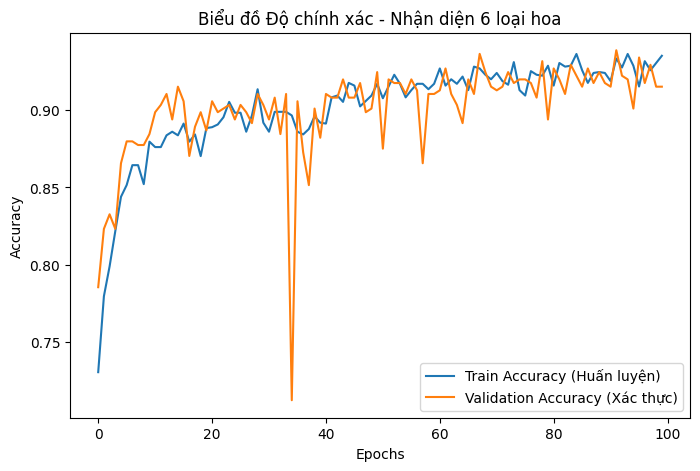

In [ ]:
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# ==========================================
# 3. HUẤN LUYỆN MÔ HÌNH
# ==========================================
epochs = 100

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs
)

# ==========================================
# 4. VẼ BIỂU ĐỒ ĐÁNH GIÁ
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label="Train Accuracy (Huấn luyện)")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy (Xác thực)")
plt.title("Biểu đồ Độ chính xác - Nhận diện 6 loại hoa")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
import pickle
model.save('/content/drive/MyDrive/Dataset_flower/bai4_flower_model.h5')

with open('/content/drive/MyDrive/Dataset_flower/bai4_flower_labels.pkl', 'wb') as f:
    pickle.dump(train_generator.class_indices, f)

print("Hoàn tất! Đã lưu mô hình (bai4_flower_model.h5) và nhãn thành công.")

Hoàn tất! Đã lưu mô hình (bai4_flower_model.h5) và nhãn thành công.


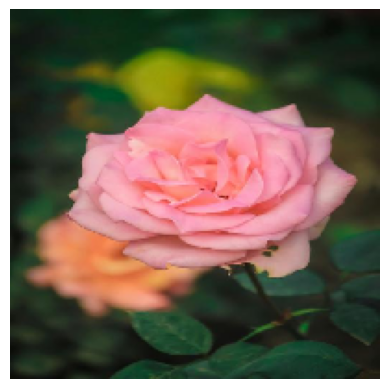

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
Loài hoa dự đoán: Hoa_mẫu_đơn
Độ chắc chắn: 99.87%


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import pickle

# 1. Tải mô hình và nhãn đã lưu
model = load_model('/content/drive/MyDrive/Dataset_flower/bai4_flower_model.h5')

with open('/content/drive/MyDrive/Dataset_flower/bai4_flower_labels.pkl', 'rb') as f:
    class_indices = pickle.load(f)

class_labels = {v: k for k, v in class_indices.items()}

# 2. Xử lý ảnh cần kiểm tra
path = "/content/hoa4.jpg" # Sửa thành đường dẫn ảnh bạn muốn test

img = load_img(path, target_size=(200, 200))
plt.imshow(img)
plt.axis('off')
plt.show()

img_arr = img_to_array(img)
img_arr = img_arr / 255.0
img_arr = np.expand_dims(img_arr, axis=0)

# 3. Tiên đoán
predictions = model.predict(img_arr)
predicted_class = np.argmax(predictions)
flower_name = class_labels[predicted_class]
confidence = np.max(predictions) * 100

print(f"Loài hoa dự đoán: {flower_name}")
print(f"Độ chắc chắn: {confidence:.2f}%")